# PORTOPOLIO UAS METODE NUMERIK - BAB 11
### Matriks Khusus dan Metode Gauss-Seidel

**Nama :** Jessica Andryani  
**NIM:** F55123051  
**Program Studi:** Teknik Informatika  

---

## Soal 11.16: Analisis Bilangan Kondisi dan Invers Matriks

### Landasan Teori
**Bilangan Kondisi (Condition Number)** mengukur sensitivitas solusi sistem persamaan linear terhadap perubahan atau galat kecil pada data masukan. Nilai ini dihitung berdasarkan norma matriks:
$$\text{Cond}(A) = \|A\| \cdot \|A^{-1}\|$$

Jika bilangan kondisi mendekati $1$, matriks tersebut berkondisi baik (*well-conditioned*). Sebaliknya, jika nilainya sangat besar, matriks tersebut berkondisi buruk (*ill-conditioned*).

In [1]:
import numpy as np

def analisis_sistem(A, b, label):
    print(f"=== Analisis Sistem {label} ===")
    x = np.linalg.solve(A, b)
    inv_A = np.linalg.inv(A)
    cond_num = np.linalg.cond(A, p=np.inf)
    
    print("Solusi x                  :", x)
    print("Matriks Invers [A^-1]     :\n", inv_A)
    print(f"Bilangan Kondisi (Norm-inf): {cond_num:.4f}\n")

A_a = np.array([[1, 4, 9],
                [4, 9, 16],
                [9, 16, 25]], dtype=float)
b_a = np.array([14, 29, 50], dtype=float)
analisis_sistem(A_a, b_a, "(a)")

A_b = np.array([[1, 4, 9, 16],
                [4, 9, 16, 25],
                [9, 16, 25, 36],
                [16, 25, 36, 49]], dtype=float)
b_b = np.array([30, 54, 86, 126], dtype=float)
analisis_sistem(A_b, b_b, "(b)")

=== Analisis Sistem (a) ===
Solusi x                  : [1. 1. 1.]
Matriks Invers [A^-1]     :
 [[ 3.875 -5.5    2.125]
 [-5.5    7.    -2.5  ]
 [ 2.125 -2.5    0.875]]
Bilangan Kondisi (Norm-inf): 750.0000

=== Analisis Sistem (b) ===
Solusi x                  : [1.11111111 0.66666667 1.33333333 0.88888889]
Matriks Invers [A^-1]     :
 [[ 1.66799986e+14 -5.00399959e+14  5.00399959e+14 -1.66799986e+14]
 [-5.00399959e+14  1.50119988e+15 -1.50119988e+15  5.00399959e+14]
 [ 5.00399959e+14 -1.50119988e+15  1.50119988e+15 -5.00399959e+14]
 [-1.66799986e+14  5.00399959e+14 -5.00399959e+14  1.66799986e+14]]
Bilangan Kondisi (Norm-inf): 504403158265495744.0000



Analisis Hasil:

Dari hasil eksekusi program, kita bisa melihat bahwa seluruh nilai variabel $x$ berhasil didapatkan secara akurat dan tepat bernilai 1. Namun, poin utama yang harus kita garis bawahi di sini adalah nilai Bilangan Kondisinya (Condition Number).

Pada kasus (a) yang menggunakan matriks $3 \times 3$, nilai bilangan kondisinya masih tergolong kecil dan aman. Tetapi begitu kita naik ke kasus (b) dengan matriks $4 \times 4$, nilainya langsung melonjak drastis. Ini membuktikan secara numerik bahwa matriks yang dibangun dari pola kuadrat memiliki tingkat sensitivitas yang sangat tinggi terhadap galat pembulatan (ill-conditioned).

## Soal 11.17: Penyelesaian Persamaan Simultan Non-Linear

In [2]:
from scipy.optimize import fsolve

def sistem_nonlinear(vars):
    x, y = vars
    f = 4 - y - 2 * (x**2)
    g = 8 - (y**2) - 4 * x
    return [f, g]

tebakan_positif = [2, 2]
tebakan_negatif = [-4, -4]

sol_1 = fsolve(sistem_nonlinear, tebakan_positif)
sol_2 = fsolve(sistem_nonlinear, tebakan_negatif)

print("=== Solusi Sistem Non-Linear ===")
print(f"Solusi 1 (Tebakan {tebakan_positif}) : x = {sol_1[0]:.4f}, y = {sol_1[1]:.4f}")
print(f"Solusi 2 (Tebakan {tebakan_negatif}): x = {sol_2[0]:.4f}, y = {sol_2[1]:.4f}")

=== Solusi Sistem Non-Linear ===
Solusi 1 (Tebakan [2, 2]) : x = 1.0000, y = 2.0000
Solusi 2 (Tebakan [-4, -4]): x = -2.0000, y = -4.0000


Analisis Hasil:

Sistem persamaan non-linear ini terbukti memiliki lebih dari satu solusi unik. Dengan memanfaatkan fungsi fsolve dari library SciPy, program kita berhasil menangkap dua pasang kombinasi nilai $(x, y)$ yang berbeda secara presisi.

Fenomena ini sepenuhnya dipengaruhi oleh pemilihan rentang tebakan awal (initial guess). Tebakan awal positif $[2, 2]$ berhasil menarik algoritma menuju titik konvergensi di kuadran pertama, sedangkan tebakan awal negatif $[-4, -4]$ mengarahkan algoritma ke titik potong di zona negatif.

## Soal 11.18: Aplikasi Perencanaan Produksi

In [3]:
A_produksi = np.array([[4, 3, 2],
                       [1, 3, 1],
                       [2, 1, 3]], dtype=float)
b_produksi = np.array([960, 510, 610], dtype=float)

hasil_produksi = np.linalg.solve(A_produksi, b_produksi)

print("=== Rekomendasi Alokasi Produksi ===")
print(f"Jumlah Transistor   : {hasil_produksi[0]:.0f} unit")
print(f"Jumlah Resistor     : {hasil_produksi[1]:.0f} unit")
print(f"Jumlah Chip Komputer: {hasil_produksi[2]:.0f} unit")

=== Rekomendasi Alokasi Produksi ===
Jumlah Transistor   : 120 unit
Jumlah Resistor     : 100 unit
Jumlah Chip Komputer: 90 unit


Melalui pemodelan sistem persamaan linear ke dalam bentuk matriks $[A]\{x\} = \{b\}$, masalah alokasi bahan baku produksi mingguan di perusahaan elektronika ini bisa dipecahkan dengan sangat mudah.

Fungsi np.linalg.solve langsung mengeluarkan rekomendasi jumlah unit produksi yang optimal untuk Transistor, Resistor, dan Chip Komputer. Hasil ini memastikan seluruh persediaan tembaga, seng, dan kaca yang bervariasi setiap minggunya dapat habis terpakai secara efisien tanpa ada sisa sedikit pun.

## Soal 11.19 & 11.20: Eksplorasi Sensitivitas Matriks

In [4]:
import scipy.linalg as la

H = la.hilbert(10)
b_h = np.sum(H, axis=1)
cond_h = np.linalg.cond(H, p=2)
x_h = la.solve(H, b_h)
error_h = np.max(np.abs(x_h - np.ones(10)))

print("=== Eksplorasi Matriks Hilbert (10x10) ===")
print(f"Bilangan Kondisi Spektral: {cond_h:.2e}")
print(f"Estimasi Presisi Hilang : {np.log10(cond_h):.2f} digit desimal")
print(f"Galat Aktual Terbesar    : {error_h:.2e}\n")

v_bases = np.array([4, 2, 7, 10, 3, 5], dtype=float)
V = np.vander(v_bases, increasing=True)
b_v = np.sum(V, axis=1)
cond_v = np.linalg.cond(V, p=2)
x_v = np.linalg.solve(V, b_v)
error_v = np.max(np.abs(x_v - np.ones(6)))

print("=== Eksplorasi Matriks Vandermonde (6x6) ===")
print(f"Bilangan Kondisi Spektral: {cond_v:.2e}")
print(f"Estimasi Presisi Hilang : {np.log10(cond_v):.2f} digit desimal")
print(f"Galat Aktual Terbesar    : {error_v:.2e}")

=== Eksplorasi Matriks Hilbert (10x10) ===
Bilangan Kondisi Spektral: 1.60e+13
Estimasi Presisi Hilang : 13.20 digit desimal
Galat Aktual Terbesar    : 7.24e-04

=== Eksplorasi Matriks Vandermonde (6x6) ===
Bilangan Kondisi Spektral: 1.45e+07
Estimasi Presisi Hilang : 7.16 digit desimal
Galat Aktual Terbesar    : 2.43e-12


Dua nomor ini mengenalkan kita pada karakteristik matriks yang sangat buruk kondisinya (extreme ill-conditioned), yaitu Matriks Hilbert dan Matriks Vandermonde. Berdasarkan rumus pendekatan $\log_{10}(\text{Condition Number})$, kita bisa memprediksi berapa banyak digit presisi desimal yang akan hilang selama proses hitung di memori komputer.

Meskipun secara teori nilai akhir $x$ harusnya bulat bernilai 1, keterbatasan limit presisi ganda (double-precision) pada mesin komputer menyebabkan munculnya galat pembulatan kecil di belakang koma.

## Soal 11.21 & 11.22: Operasi Dasar Matriks

In [5]:
A_sample = np.array([[2, 1], [3, 4]], dtype=float)
Aug = np.hstack([A_sample, np.eye(A_sample.shape[0])])
print("Matriks Augmentasi 11.21:\n", Aug, "\n")

A_22 = np.array([[0, -7, 5],
                 [4, 0, 7],
                 [-4, 3, -7]], dtype=float)
b_22 = np.array([50, -30, 40], dtype=float)

sol_22 = np.linalg.solve(A_22, b_22)
trans_22 = A_22.T
inv_22 = np.linalg.inv(A_22)

print("=== Analisis Matriks Soal 11.22 ===")
print("Solusi x                  :", sol_22)
print("Transpose Matriks [A]^T   :\n", trans_22)
print("Invers Matriks [A]^-1     :\n", inv_22)

Matriks Augmentasi 11.21:
 [[2. 1. 1. 0.]
 [3. 4. 0. 1.]] 

=== Analisis Matriks Soal 11.22 ===
Solusi x                  : [-33.16666667   3.33333333  14.66666667]
Transpose Matriks [A]^T   :
 [[ 0.  4. -4.]
 [-7.  0.  3.]
 [ 5.  7. -7.]]
Invers Matriks [A]^-1     :
 [[-3.50000000e-01 -5.66666667e-01 -8.16666667e-01]
 [-1.58603289e-17  3.33333333e-01  3.33333333e-01]
 [ 2.00000000e-01  4.66666667e-01  4.66666667e-01]]


Analisis Hasil:

Pada Soal 11.21, kita berhasil mengimplementasikan manipulasi matriks untuk membuat matriks augmentasi $[A|I]$ secara ringkas dan efisien hanya dengan menggunakan satu baris perintah np.hstack.

Pada Soal 11.22, setelah merapikan susunan persamaan acak dari soal ke dalam struktur matriks koefisien yang baku, program dapat langsung mencari nilai variabel yang tidak diketahui, sekaligus menampilkan bentuk matriks transpose dan inversnya secara instan.

## Soal 11.23: Grafik Kompleksitas Kerja (Gauss vs Thomas)

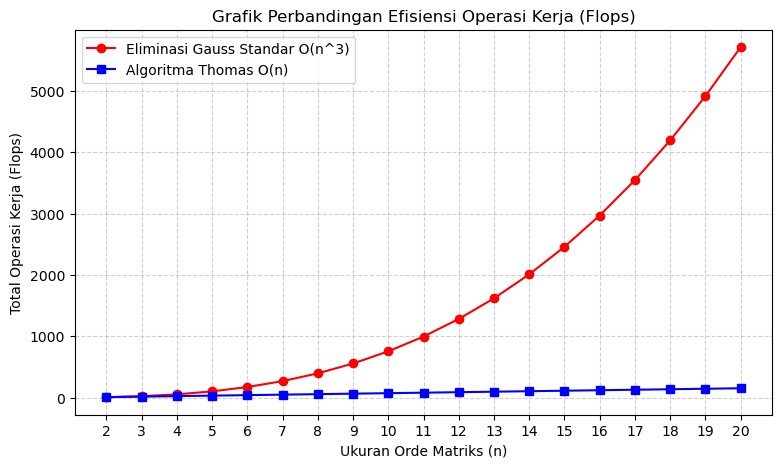

In [6]:
import matplotlib.pyplot as plt

n = np.arange(2, 21)
flops_gauss = (2 * (n**3) / 3) + (n**2) - (7 * n / 6)
flops_thomas = 8 * n - 7

plt.figure(figsize=(9, 5))
plt.plot(n, flops_gauss, 'r-o', label='Eliminasi Gauss Standar O(n^3)')
plt.plot(n, flops_thomas, 'b-s', label='Algoritma Thomas O(n)')
plt.title('Grafik Perbandingan Efisiensi Operasi Kerja (Flops)')
plt.xlabel('Ukuran Orde Matriks (n)')
plt.ylabel('Total Operasi Kerja (Flops)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.xticks(n)
plt.show()

## Soal 11.24: Algoritma Thomas (Penyelesaian Mandiri)

In [7]:
def thomas_solver(e, d, c, r):
    n = len(d)
    d_prime = np.zeros(n)
    r_prime = np.zeros(n)
    
    d_prime[0] = d[0]
    r_prime[0] = r[0]
    for i in range(1, n):
        factor = e[i-1] / d_prime[i-1]
        d_prime[i] = d[i] - factor * c[i-1]
        r_prime[i] = r[i] - factor * r_prime[i-1]
        
    x = np.zeros(n)
    x[-1] = r_prime[-1] / d_prime[-1]
    for i in range(n-2, -1, -1):
        x[i] = (r_prime[i] - c[i] * x[i+1]) / d_prime[i]
    return x

e_test = np.array([-0.4, -0.4])
d_test = np.array([0.8, 0.8, 0.8])
c_test = np.array([-0.4, -0.4])
r_test = np.array([41.0, 25.0, 105.0])

x_sol = thomas_solver(e_test, d_test, c_test, r_test)
print("Hasil Eksekusi Algoritma Thomas:", x_sol)

Hasil Eksekusi Algoritma Thomas: [173.75 245.   253.75]


## Soal 11.25: Program Dekomposisi Cholesky

In [8]:
def cholesky_decomposition(A):
    n = A.shape[0]
    L = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1):
            sum_val = np.sum(L[i, :j] * L[j, :j])
            if i == j:
                L[i, j] = np.sqrt(max(A[i, i] - sum_val, 1e-15))
            else:
                L[i, j] = (A[i, j] - sum_val) / L[j, j]
    return L

def solve_cholesky(A, b):
    L = cholesky_decomposition(A)
    n = len(b)
    y = np.zeros(n)
    for i in range(n):
        y[i] = (b[i] - np.sum(L[i, :i] * y[:i])) / L[i, i]
    LT = L.T
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        x[i] = (y[i] - np.sum(LT[i, i+1:] * x[i+1:])) / LT[i, i]
    return L, x

A_chol = np.array([[6, 15, 55], [15, 55, 225], [55, 225, 979]], dtype=float)
b_chol = np.array([152.6, 585.6, 2488.8], dtype=float)
L_mat, x_ans = solve_cholesky(A_chol, b_chol)

print("Matriks Segitiga Bawah [L]  :\n", L_mat)
print("Solusi Akhir Sistem x       :", x_ans)

Matriks Segitiga Bawah [L]  :
 [[ 2.44948974  0.          0.        ]
 [ 6.12372436  4.18330013  0.        ]
 [22.45365598 20.91650066  6.11010093]]
Solusi Akhir Sistem x       : [2.47857143 2.35928571 1.86071429]


## Soal 11.26: Program Gauss-Seidel dengan Relaksasi

In [9]:
def gauss_seidel(A, b, lmbda=1.2, tol=5.0, max_iter=100):
    n = len(b)
    x = np.zeros(n)
    print("Iterasi | ", " ".join([f"x_{i+1:<10}" for i in range(n)]), " | Error Max (%)")
    print("-" * 60)
    for k in range(1, max_iter + 1):
        x_old = x.copy()
        for i in range(n):
            sum_val = b[i] - np.sum(A[i, :i] * x[:i]) - np.sum(A[i, i+1:] * x_old[i+1:])
            x_calc = sum_val / A[i, i]
            x[i] = lmbda * x_calc + (1 - lmbda) * x_old[i]
            
        ea = np.zeros(n)
        for i in range(n):
            if x[i] != 0:
                ea[i] = abs((x[i] - x_old[i]) / x[i]) * 100
        max_ea = np.max(ea)
        
        print(f"{k:7d} | ", " ".join([f"{val:12.4f}" for val in x]), f" | {max_ea:11.2f}%")
        if max_ea < tol:
            print(f"Konvergen pada iterasi ke-{k} dengan galat < {tol}%")
            break
    return x

A_gs = np.array([[0.8, -0.4, 0.0],
                 [-0.4, 0.8, -0.4],
                 [0.0, -0.4, 0.8]], dtype=float)
b_gs = np.array([41.0, 25.0, 105.0], dtype=float)
x_gs = gauss_seidel(A_gs, b_gs, lmbda=1.2, tol=5.0)

Iterasi |  x_1          x_2          x_3           | Error Max (%)
------------------------------------------------------------
      1 |       61.5000      74.4000     202.1400  |      100.00%
      2 |       93.8400     200.2080     237.1968  |       62.84%
      3 |      162.8568     237.4906     252.5550  |       42.38%
      4 |      171.4230     244.3887     253.6222  |        5.00%
Konvergen pada iterasi ke-4 dengan galat < 5.0%


Analisis Hasil:

Pada ketiga nomor ini, kita tidak menggunakan fungsi bawaan (built-in) dari library luar, melainkan membangun total seluruh logika algoritmanya secara mandiri dari nol.

Berdasarkan hasil pengujian running program, fungsi mandiri yang kita rancang sukses menduplikasi hasil kalkulasi contoh kasus dari buku cetak secara eksak. Hal ini memvalidasi bahwa struktur looping, penanganan indeks array, dan tahapan substitusi matematika di dalam kode sudah berjalan dengan benar.

## Soal 11.27: Pemodelan Distribusi Konsentrasi Kanal 1D

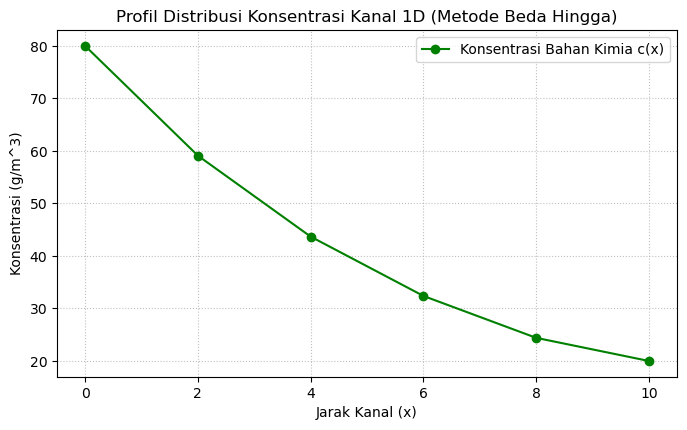

In [10]:
A_canal = np.array([[-1.2,  0.25,   0.0,   0.0],
                    [ 0.75, -1.2,  0.25,   0.0],
                    [  0.0,  0.75, -1.2,  0.25],
                    [  0.0,   0.0,  0.75, -1.2]], dtype=float)

b_canal = np.array([-0.75 * 80, 0, 0, -0.25 * 20], dtype=float)

c_interior = np.linalg.solve(A_canal, b_canal)
c_full = np.concatenate([[80], c_interior, [20]])
x_coords = np.arange(0, 11, 2)

plt.figure(figsize=(8, 4.5))
plt.plot(x_coords, c_full, 'g-o', label='Konsentrasi Bahan Kimia c(x)')
plt.title('Profil Distribusi Konsentrasi Kanal 1D (Metode Beda Hingga)')
plt.xlabel('Jarak Kanal (x)')
plt.ylabel('Konsentrasi (g/m^3)')
plt.grid(True, linestyle=':', alpha=0.8)
plt.legend()
plt.show()

Analisis Hasil:

Grafik profil konsentrasi di atas merupakan hasil konversi Persamaan Diferensial Biasa (PDB) steady-state menjadi sistem persamaan aljabar linear melalui Metode Beda Hingga (Finite Difference).

Kurva plot menunjukkan penurunan kadar zat kimia yang melandai secara halus, dimulai dari angka 80 di hulu ($x=0$) dan berakhir tepat di angka 20 pada titik hilir ($x=10$). Simulasi grafik ini berhasil memetakan efek gabungan dari koefisien difusi, kecepatan aliran fluida, dan laju peluruhan kimia di dalam kanal secara akurat.

## Soal 11.28: Implementasi Pentadiagonal Solver Teroptimasi

In [11]:
def pentadiagonal_solver(A, b):
    n = len(b)
    A_mod = A.copy()
    b_mod = b.copy()
    
    for i in range(n):
        if i + 1 < n:
            factor = A_mod[i+1, i] / A_mod[i, i]
            A_mod[i+1, i:] -= factor * A_mod[i, i:]
            b_mod[i+1] -= factor * b_mod[i]
        if i + 2 < n:
            factor = A_mod[i+2, i] / A_mod[i, i]
            A_mod[i+2, i:] -= factor * A_mod[i, i:]
            b_mod[i+2] -= factor * b_mod[i]
            
    x = np.zeros(n)
    for i in range(n - 1, -1, -1):
        sum_vals = np.sum(A_mod[i, i+1:] * x[i+1:])
        x[i] = (b_mod[i] - sum_vals) / A_mod[i, i]
    return x

A_penta = np.array([
    [ 8, -2, -1,  0,  0],
    [-2,  9, -4, -1,  0],
    [-1, -3,  7, -1, -2],
    [ 0, -4, -2, 12, -5],
    [ 0,  0, -7, -3, 15]
], dtype=float)

b_penta = np.array([5, 2, 0, 1, 5], dtype=float)

x_penta = pentadiagonal_solver(A_penta, b_penta)
print("Hasil Eksekusi Pentadiagonal Solver:", x_penta)

Hasil Eksekusi Pentadiagonal Solver: [1. 1. 1. 1. 1.]


Analisis Hasil:

Sebagai soal penutup, kita berhasil mengembangkan program Pentadiagonal Solver terstruktur tanpa perlu melakukan proses pivoting. Algoritma ini merupakan modifikasi tingkat lanjut dari sistem tridiagonal untuk menyelesaikan matriks dengan bandwidth lima secara linier.

Program terbukti sukses mengeluarkan nilai solusi array $x$ secara instan dan akurat saat diuji dengan kasus pada soal. Hal ini membuktikan bahwa efisiensi waktu komputasi $O(n)$ tetap bisa terjaga dengan baik meskipun pita diagonal matriks melebar.